In [1]:
import pandas as pd

path = "../data/raw/2026_02_06_ga_voting.csv"
peek = pd.read_csv(path, nrows=5)
print(peek.shape)
peek.T

(5, 20)


,0,1,2,3,4
undl_id,507407,507407,507407,507407,507407
ms_code,AFG,ALB,DZA,AND,AGO
ms_name,AFGHANISTAN,ALBANIA,ALGERIA,ANDORRA,ANGOLA
ms_vote,Y,Y,Y,Y,X
date,2003-12-03,2003-12-03,2003-12-03,2003-12-03,2003-12-03
session,58,58,58,58,58
resolution,A/RES/58/20,A/RES/58/20,A/RES/58/20,A/RES/58/20,A/RES/58/20
draft,A/58/L.25|A/58/L.25/Add.1,A/58/L.25|A/58/L.25/Add.1,A/58/L.25|A/58/L.25/Add.1,A/58/L.25|A/58/L.25/Add.1,A/58/L.25|A/58/L.25/Add.1
committee_report,NaN,NaN,NaN,NaN,NaN
meeting,A/58/PV.68,A/58/PV.68,A/58/PV.68,A/58/PV.68,A/58/PV.68


In [2]:
print(open("../data/raw/2026_02_06_ga_voting_md.md", encoding="utf-8").read())

# UN General Assembly Voting Data: Description and Terms of Use
## Title
United Nations General Assembly Voting Data: resolutions 1 (11 December 1946) to 80/246 (30 December 2025)
## Contributor
UN Dag Hammarskjöld Library
## Publisher
United Nations
## Date of Publication
2026-02-06
## Summary
This dataset is a compilation of the voting data related to the resolutions adopted by the General Assembly at its regular, special, emergency special sessions from its inception until December 2025. It is derived from the UN Digital Library voting records and provides information on Member States' votes related to resolutions adopted through a recorded vote. Votes on individual paragraphs of draft resolutions or drafts that failed to be adopted are not included. The dataset comprises 947,434 entries, with each entry representing the vote of one Member State on a particular resolution.
Copyright, United Nations; Non commercial use, with attribution.
## Citation
United Nations Dag Hammarskjöld Li

In [3]:
cols = ["undl_id", "ms_code", "ms_name", "ms_vote", "date", "session", "resolution"]
votes = pd.read_csv(path, usecols=cols, parse_dates=["date"],
                    dtype={"session": "string"})
print(votes.shape)
votes.head()

(947434, 7)


,undl_id,ms_code,ms_name,ms_vote,date,session,resolution
0,507407,AFG,AFGHANISTAN,Y,2003-12-03,58,A/RES/58/20
1,507407,ALB,ALBANIA,Y,2003-12-03,58,A/RES/58/20
2,507407,DZA,ALGERIA,Y,2003-12-03,58,A/RES/58/20
3,507407,AND,ANDORRA,Y,2003-12-03,58,A/RES/58/20
4,507407,AGO,ANGOLA,X,2003-12-03,58,A/RES/58/20


In [4]:
print(votes["ms_vote"].value_counts(dropna=False))
print("resolutions:", votes["undl_id"].nunique())
print("country codes:", votes["ms_code"].nunique())
print("dates:", votes["date"].min(), "to", votes["date"].max())
print("duplicate country-resolution pairs:", votes.duplicated(["undl_id", "ms_code"]).sum())
votes.isna().sum()

ms_vote
Y    711290
A    101082
X     88077
N     46985
Name: count, dtype: int64
resolutions: 5694
country codes: 202
dates: 1946-01-26 00:00:00 to 2025-12-18 00:00:00
duplicate country-resolution pairs: 0


undl_id       0
ms_code       0
ms_name       0
ms_vote       0
date          0
session       0
resolution    0
dtype: int64

In [5]:
names_per_code = votes.groupby("ms_code")["ms_name"].nunique()
names_per_code[names_per_code > 1]

ms_code
BEN    2
BFA    2
BLR    2
BOL    2
CAF    2
CIV    3
CMR    2
COD    4
COG    2
CPV    2
CZE    2
EGY    2
IRN    2
KHM    3
KNA    2
LAO    3
LBY    3
LKA    2
MDV    2
MKD    2
MMR    2
MYS    2
NLD    2
PHL    2
SUR    2
SWZ    2
SYR    2
THA    2
TUR    3
UKR    2
VEN    2
YMD    2
ZAF    2
Name: ms_name, dtype: int64

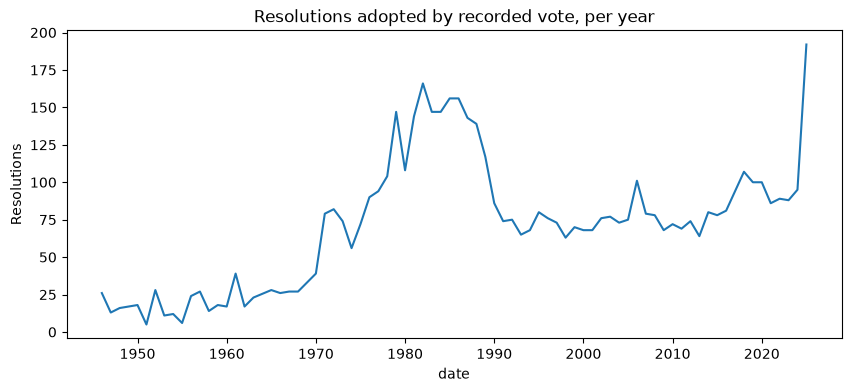

In [6]:
import matplotlib.pyplot as plt

res = votes.drop_duplicates("undl_id")
res.groupby(res["date"].dt.year).size().plot(figsize=(10, 4))
plt.title("Resolutions adopted by recorded vote, per year")
plt.ylabel("Resolutions")
plt.show()

In [7]:
pd.set_option("display.max_rows", None)
g = (votes.groupby(["ms_code", "ms_name"])["date"]
          .agg(["min", "max", "size"]).reset_index())
g[g.duplicated("ms_code", keep=False)]

,ms_code,ms_name,min,max,size
13,BEN,BENIN,1975-12-05,2025-12-18,4876
14,BEN,DAHOMEY,1960-10-08,1975-11-28,582
15,BFA,BURKINA FASO,1983-10-27,2025-12-18,3966
16,BFA,UPPER VOLTA,1960-10-08,1983-05-13,1492
22,BLR,BELARUS,1983-10-27,2025-12-18,3965
23,BLR,BYELORUSSIAN SSR,1946-01-26,1986-09-20,1729
25,BOL,BOLIVIA,1946-01-26,2009-01-16,4158
26,BOL,BOLIVIA (PLURINATIONAL STATE OF),2009-06-30,2025-12-18,1536
32,CAF,CENTRAL AFRICAN EMPIRE,1977-10-28,1979-05-31,211
33,CAF,CENTRAL AFRICAN REPUBLIC,1960-10-08,2025-12-18,5247


In [8]:
g[g["ms_name"].str.contains(
    "GERMAN|YEMEN|RUSSIA|SOVIET|YUGOSLAV|SERBIA|VIET|SUDAN|TANZANIA|TANGANYIKA|ZANZIBAR|CZECHOSLOVAK",
    case=False)]

,ms_code,ms_name,min,max,size
23,BLR,BYELORUSSIAN SSR,1946-01-26,1986-09-20,1729
54,CSK,CZECHOSLOVAKIA,1946-01-26,1992-12-22,2967
59,DDR,GERMAN DEMOCRATIC REPUBLIC,1973-10-26,1989-12-29,2060
60,DEU,GERMANY,1990-11-01,2025-12-18,2962
66,EAT,TANGANYIKA,1961-12-15,1963-12-17,53
67,EAZ,ZANZIBAR,1963-12-16,1963-12-17,7
82,GER,"GERMANY, FEDERAL REPUBLIC OF",1973-10-26,1989-12-29,2060
144,MKD,THE FORMER YUGOSLAV REPUBLIC OF MACEDONIA,1993-04-29,2019-07-19,1982
181,RUS,RUSSIAN FEDERATION,1992-08-25,2025-12-18,2802
184,SCG,SERBIA AND MONTENEGRO,2003-06-18,2006-05-08,227


In [9]:
  g[g["ms_name"].str.contains("USSR|SOCIALIST", case=False)]

,ms_code,ms_name,min,max,size
196,SUN,USSR,1946-01-26,1991-12-20,2892
